# Classification: KNeighborsClassifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, roc_curve, classification_report



In [2]:
st = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\INT-234-CA-2 Project\Classification\satellite_dataset_18_columns.csv")
st.head()

,timestamp,temperature_c,humidity_percent,pressure_pa,gas_ppm,radiation_uSv_h,battery_voltage_v,solar_current_ma,cpu_temp_c,vibration_mms,satellite_mode,region,fault_flag,battery_voltage_next,altitude_m,magnetic_field_uT,solar_panel_temp_c,gyro_stability_index
0,2025-01-01 00:00:00,21.83,31.41,100495.90,NaN,0.0870,7.631,443.92,30.52,2.527,NaN,EUROPE,NO,8.492,399833.626619,NaN,41.105207,0.211557
1,2025-01-01 00:00:01,13.76,37.19,101770.60,344.31,0.0619,6.847,312.65,50.26,2.523,ACTIVE,AFRICA,YES,7.433,400466.959447,44.358010,23.396596,0.210636
2,2025-01-01 00:00:02,24.50,18.22,101295.98,188.44,0.1733,7.328,533.32,47.60,2.344,NaN,AMERICA,NO,NaN,400204.991027,47.145225,NaN,0.414807
3,2025-01-01 00:00:03,25.64,27.72,101025.05,264.16,NaN,7.073,228.89,39.94,3.353,ACTIVE,ASIA,NO,7.518,400295.221921,47.505118,NaN,0.846881
4,NaN,8.29,NaN,101199.59,320.70,0.0000,8.259,148.30,35.75,1.690,NaN,AMERICA,NO,8.562,399774.287427,NaN,12.736427,0.274114


In [3]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             9173 non-null   object 
 1   temperature_c         9183 non-null   float64
 2   humidity_percent      9248 non-null   float64
 3   pressure_pa           9226 non-null   float64
 4   gas_ppm               9215 non-null   float64
 5   radiation_uSv_h       9210 non-null   float64
 6   battery_voltage_v     9236 non-null   float64
 7   solar_current_ma      9156 non-null   float64
 8   cpu_temp_c            9185 non-null   float64
 9   vibration_mms         9232 non-null   float64
 10  satellite_mode        9194 non-null   object 
 11  region                9233 non-null   object 
 12  fault_flag            9221 non-null   object 
 13  battery_voltage_next  9227 non-null   float64
 14  altitude_m            9199 non-null   float64
 15  magnetic_field_uT   

In [4]:
st.describe()

,temperature_c,humidity_percent,pressure_pa,gas_ppm,radiation_uSv_h,battery_voltage_v,solar_current_ma,cpu_temp_c,vibration_mms,battery_voltage_next,altitude_m,magnetic_field_uT,solar_panel_temp_c,gyro_stability_index
count,9183.000000,9248.000000,9226.000000,9215.000000,9210.000000,9236.000000,9156.000000,9185.000000,9232.000000,9227.000000,9199.000000,9211.000000,9194.000000,9186.000000
mean,19.907931,30.176755,101331.338930,348.557987,0.148778,7.397753,351.033456,44.839975,2.002413,8.080327,399999.805406,45.042701,24.898949,0.501696
std,6.050557,7.998251,500.487546,120.051471,0.068255,0.300107,120.991930,8.002649,0.803750,0.380689,198.707756,5.090694,10.080939,0.196495
min,-6.330000,0.000000,99559.800000,0.000000,0.000000,6.228000,0.000000,13.890000,0.000000,6.734000,399251.610127,20.921796,-12.737654,0.000000
25%,15.890000,24.730000,100993.825000,268.780000,0.101425,7.198000,269.002500,39.550000,1.455000,7.822000,399865.541206,41.647107,18.015063,0.369348
50%,19.880000,30.070000,101333.085000,347.900000,0.147800,7.398000,350.320000,44.750000,1.998500,8.087000,399998.057843,45.055450,24.861723,0.502762
75%,23.880000,35.580000,101664.982500,429.065000,0.195200,7.596000,433.182500,50.200000,2.548000,8.337000,400133.457666,48.482230,31.736753,0.637874
max,44.150000,63.210000,103166.250000,869.230000,0.500500,8.656000,785.240000,77.230000,4.984000,9.000000,400742.226349,67.925339,64.789485,1.000000


# Preprocessing

In [5]:
st.isnull().sum()

timestamp               827
temperature_c           817
humidity_percent        752
pressure_pa             774
gas_ppm                 785
radiation_uSv_h         790
battery_voltage_v       764
solar_current_ma        844
cpu_temp_c              815
vibration_mms           768
satellite_mode          806
region                  767
fault_flag              779
battery_voltage_next    773
altitude_m              801
magnetic_field_uT       789
solar_panel_temp_c      806
gyro_stability_index    814
dtype: int64

In [6]:
def num_null(col):
    for c in col:
        st[c] = st[c].fillna(st[c].mean())

def cat_null(col):
    for c in col:
        st[c] = st[c].fillna(st[c].mode()[0])

In [7]:
num_cols = st.select_dtypes(include="float").columns
cat_cols = st.select_dtypes(include="object").columns

num_null(num_cols)
cat_null(cat_cols)

In [8]:
st.isnull().sum()

timestamp               0
temperature_c           0
humidity_percent        0
pressure_pa             0
gas_ppm                 0
radiation_uSv_h         0
battery_voltage_v       0
solar_current_ma        0
cpu_temp_c              0
vibration_mms           0
satellite_mode          0
region                  0
fault_flag              0
battery_voltage_next    0
altitude_m              0
magnetic_field_uT       0
solar_panel_temp_c      0
gyro_stability_index    0
dtype: int64

In [9]:
st.head()

,timestamp,temperature_c,humidity_percent,pressure_pa,gas_ppm,radiation_uSv_h,battery_voltage_v,solar_current_ma,cpu_temp_c,vibration_mms,satellite_mode,region,fault_flag,battery_voltage_next,altitude_m,magnetic_field_uT,solar_panel_temp_c,gyro_stability_index
0,2025-01-01 00:00:00,21.83,31.410000,100495.90,348.557987,0.087000,7.631,443.92,30.52,2.527,SAFE,EUROPE,NO,8.492000,399833.626619,45.042701,41.105207,0.211557
1,2025-01-01 00:00:01,13.76,37.190000,101770.60,344.310000,0.061900,6.847,312.65,50.26,2.523,ACTIVE,AFRICA,YES,7.433000,400466.959447,44.358010,23.396596,0.210636
2,2025-01-01 00:00:02,24.50,18.220000,101295.98,188.440000,0.173300,7.328,533.32,47.60,2.344,SAFE,AMERICA,NO,8.080327,400204.991027,47.145225,24.898949,0.414807
3,2025-01-01 00:00:03,25.64,27.720000,101025.05,264.160000,0.148778,7.073,228.89,39.94,3.353,ACTIVE,ASIA,NO,7.518000,400295.221921,47.505118,24.898949,0.846881
4,2025-01-01 00:00:00,8.29,30.176755,101199.59,320.700000,0.000000,8.259,148.30,35.75,1.690,SAFE,AMERICA,NO,8.562000,399774.287427,45.042701,12.736427,0.274114


In [10]:
lb = LabelEncoder()
def encode(col):
    for c in col:
        st[c] = lb.fit_transform(st[c])

encode(cat_cols)


In [11]:
st.head()

,timestamp,temperature_c,humidity_percent,pressure_pa,gas_ppm,radiation_uSv_h,battery_voltage_v,solar_current_ma,cpu_temp_c,vibration_mms,satellite_mode,region,fault_flag,battery_voltage_next,altitude_m,magnetic_field_uT,solar_panel_temp_c,gyro_stability_index
0,0,21.83,31.410000,100495.90,348.557987,0.087000,7.631,443.92,30.52,2.527,2,3,0,8.492000,399833.626619,45.042701,41.105207,0.211557
1,1,13.76,37.190000,101770.60,344.310000,0.061900,6.847,312.65,50.26,2.523,0,0,1,7.433000,400466.959447,44.358010,23.396596,0.210636
2,2,24.50,18.220000,101295.98,188.440000,0.173300,7.328,533.32,47.60,2.344,2,1,0,8.080327,400204.991027,47.145225,24.898949,0.414807
3,3,25.64,27.720000,101025.05,264.160000,0.148778,7.073,228.89,39.94,3.353,0,2,0,7.518000,400295.221921,47.505118,24.898949,0.846881
4,0,8.29,30.176755,101199.59,320.700000,0.000000,8.259,148.30,35.75,1.690,2,1,0,8.562000,399774.287427,45.042701,12.736427,0.274114


# Visualizations for EDA (Exploratory Data Analysis)

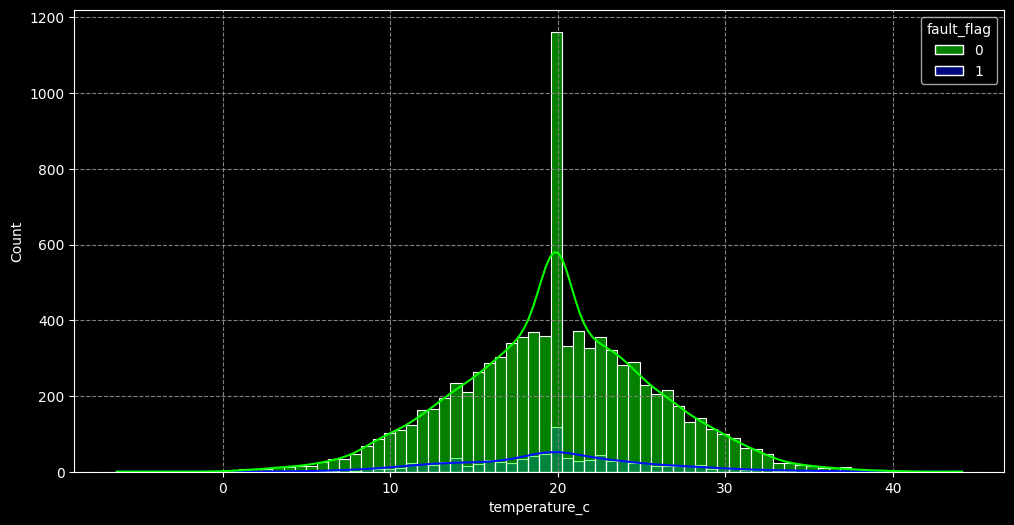

In [12]:
plt.style.use("dark_background")
plt.figure(figsize=(12, 6))
sns.histplot(data=st, x='temperature_c', hue='fault_flag', kde=True, palette="hsv")
plt.grid(color='gray', linestyle='--')
plt.show()

In [13]:
st['timestamp'] = pd.to_datetime(st['timestamp'], errors='coerce')

st['day'] = st['timestamp'].dt.day
st['month'] = st['timestamp'].dt.month
st['year'] = st['timestamp'].dt.year

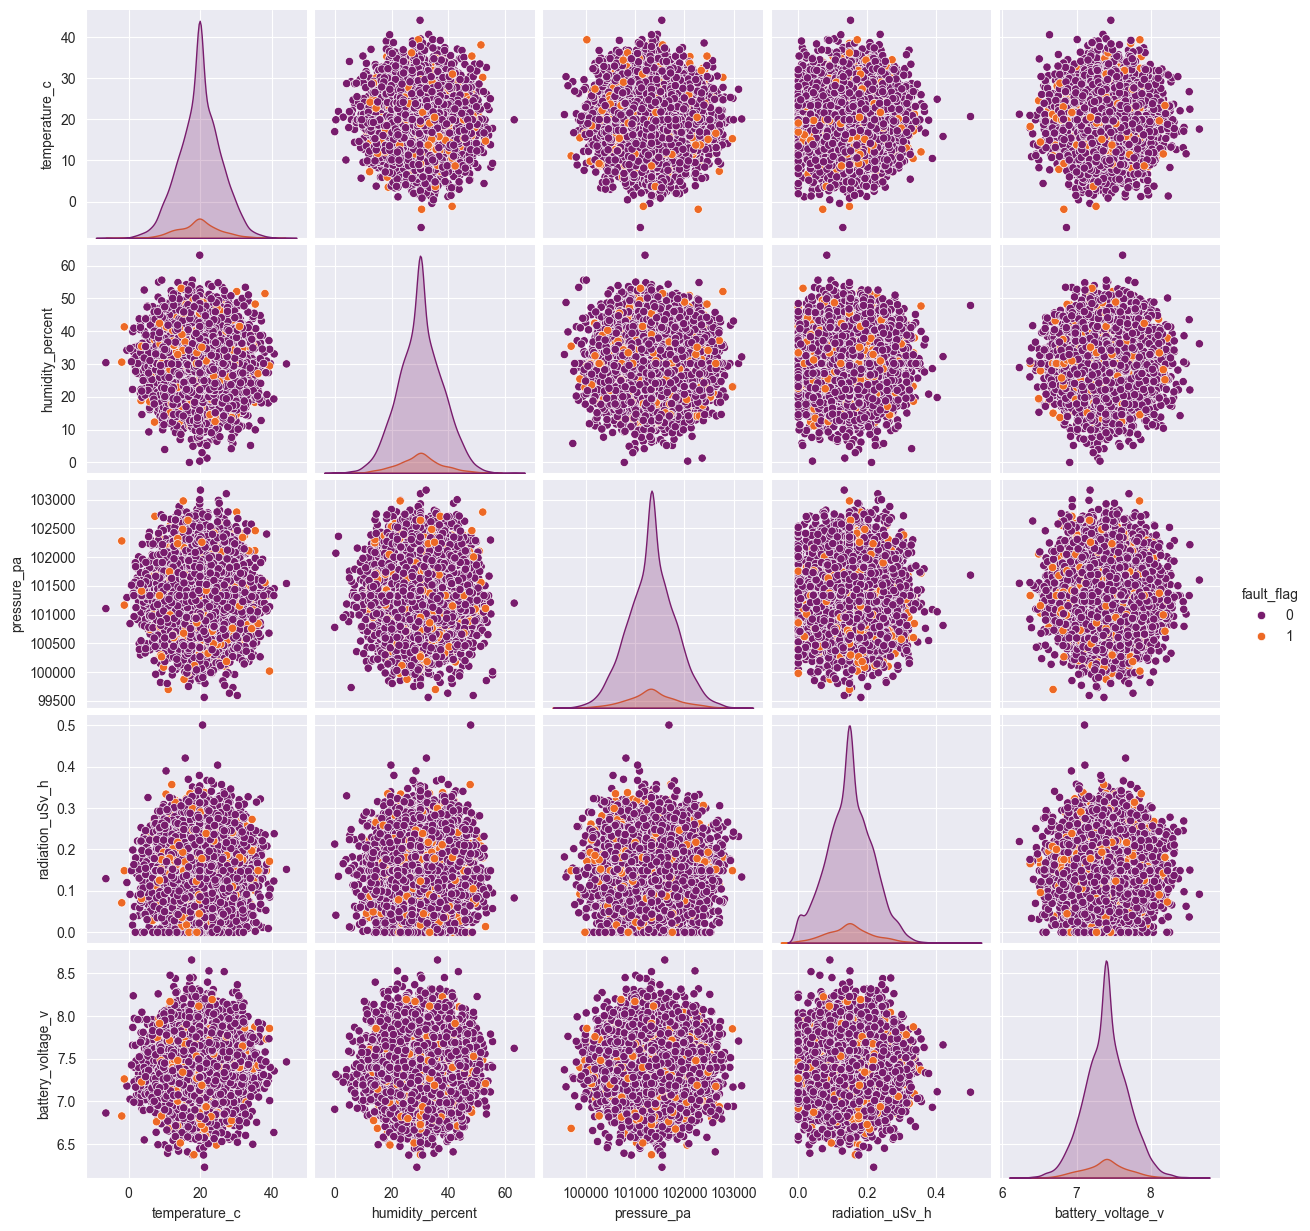

In [14]:
plt.style.use("dark_background")
sns.set_style("darkgrid")
pair = st[["temperature_c", "humidity_percent", "pressure_pa",  "fault_flag","radiation_uSv_h", "battery_voltage_v"]]
sns.pairplot(pair, hue="fault_flag", palette="inferno", diag_kind="kde")
plt.show()

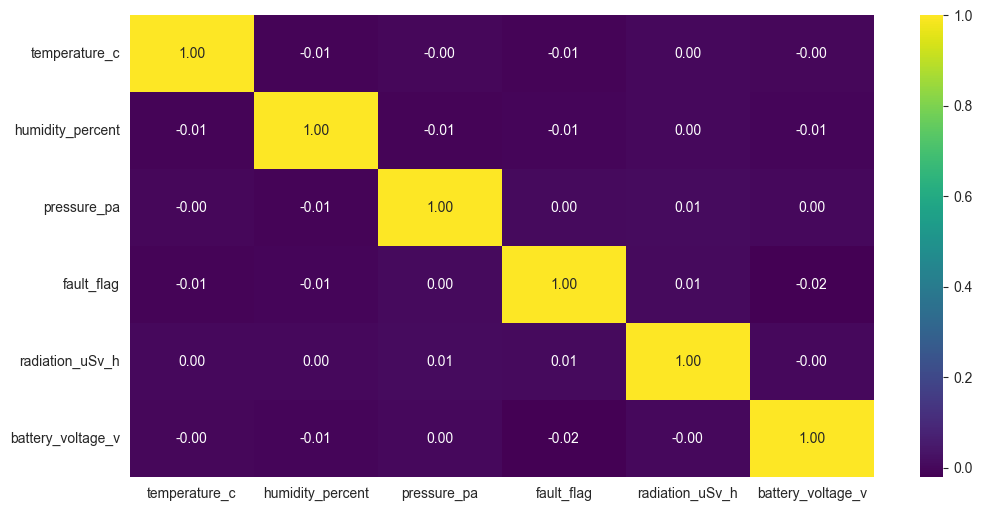

In [15]:

plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
num_cols = st[["temperature_c", "humidity_percent", "pressure_pa",  "fault_flag","radiation_uSv_h", "battery_voltage_v"]]
corr_num = num_cols.corr()
sns.heatmap(corr_num, cmap='viridis', annot=True, fmt='.2f')
plt.show()



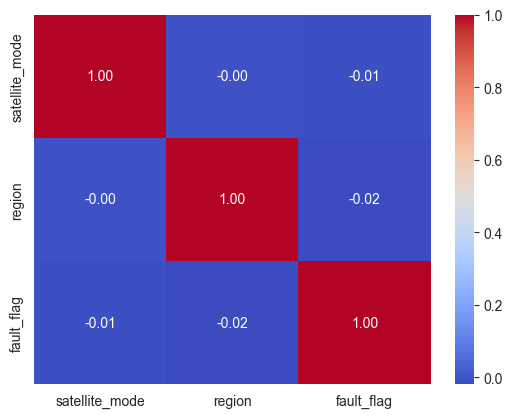

In [16]:
cat_cols = st[["satellite_mode","region","fault_flag"]]
corr_cat = cat_cols.corr()
sns.heatmap(corr_cat, cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

In [17]:
st.head()

,timestamp,temperature_c,humidity_percent,pressure_pa,gas_ppm,radiation_uSv_h,battery_voltage_v,solar_current_ma,cpu_temp_c,vibration_mms,...,region,fault_flag,battery_voltage_next,altitude_m,magnetic_field_uT,solar_panel_temp_c,gyro_stability_index,day,month,year
0,1970-01-01 00:00:00.000000000,21.83,31.410000,100495.90,348.557987,0.087000,7.631,443.92,30.52,2.527,...,3,0,8.492000,399833.626619,45.042701,41.105207,0.211557,1,1,1970
1,1970-01-01 00:00:00.000000001,13.76,37.190000,101770.60,344.310000,0.061900,6.847,312.65,50.26,2.523,...,0,1,7.433000,400466.959447,44.358010,23.396596,0.210636,1,1,1970
2,1970-01-01 00:00:00.000000002,24.50,18.220000,101295.98,188.440000,0.173300,7.328,533.32,47.60,2.344,...,1,0,8.080327,400204.991027,47.145225,24.898949,0.414807,1,1,1970
3,1970-01-01 00:00:00.000000003,25.64,27.720000,101025.05,264.160000,0.148778,7.073,228.89,39.94,3.353,...,2,0,7.518000,400295.221921,47.505118,24.898949,0.846881,1,1,1970
4,1970-01-01 00:00:00.000000000,8.29,30.176755,101199.59,320.700000,0.000000,8.259,148.30,35.75,1.690,...,1,0,8.562000,399774.287427,45.042701,12.736427,0.274114,1,1,1970


In [18]:
st = st.drop(columns=["timestamp", "day","month","year"])

In [19]:
X = st.drop("fault_flag", axis=1)
y = st["fault_flag"]

scl = StandardScaler()
Xs = scl.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
ml = KNeighborsClassifier(n_neighbors=9)
ml.fit(X_train, y_train)

yp = ml.predict(X_test)

acc = accuracy_score(yp, y_test)
cm = confusion_matrix(yp, y_test)

In [21]:
print("Accuracy: ", acc* 100,"%")
print("Confusion Matrix: \n", cm)

Accuracy:  90.95 %
Confusion Matrix: 
 [[1818  181]
 [   0    1]]


In [22]:
import joblib as jb

jb.dump(ml, "KNN_SAT_NOVA.pkl")

['KNN_SAT_NOVA.pkl']